In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [3]:
# df = pd.read_csv('data/clean-thinning-data-2.csv')
df = pd.read_csv('data/pre-thin-data.csv')
df.head()

,Row,Tree,pre_DBH,pre_HT,pre_LLC,pre_stem_vol
0,1,1,10.8,69.788672,NaN,19.593049
1,1,2,6.8,62.771152,NaN,7.127531
2,1,3,6.1,60.770923,NaN,5.601351
3,1,4,5.5,58.873375,NaN,4.458079
4,1,5,10.5,69.522875,NaN,18.461945


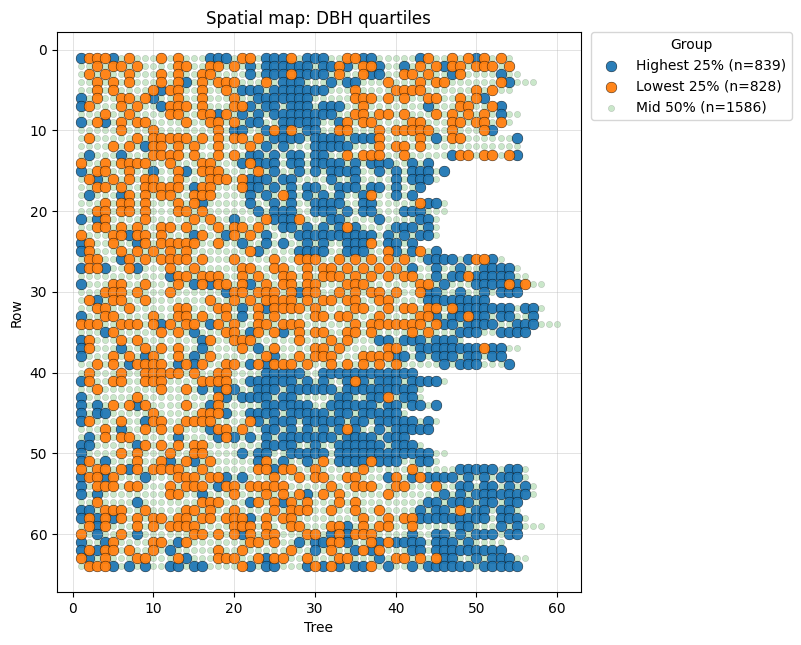

In [4]:
def percentile_flags(df,metric='pre_DBH',alive=True):
    d=df.copy()
    if alive and 'status' in d.columns:
        d=d[d['status']=='Alive']
    vals=d[metric].dropna()
    q1,q3=vals.quantile(0.25),vals.quantile(0.75)
    d['quartile']='Mid 50%'
    d.loc[d[metric]<=q1,'quartile']='Lowest 25%'
    d.loc[d[metric]>=q3,'quartile']='Highest 25%'
    return d,q1,q3

def percentile_map_plot(df,metric='pre_DBH',row_col=('Row','Tree'),alive=True,title=None):
    d,q1,q3=percentile_flags(df,metric,alive=alive)
    r,c=row_col

    order=['Lowest 25%','Mid 50%','Highest 25%']
    counts=(d['quartile'].value_counts()
              .reindex(order)
              .fillna(0).astype(int)
              .to_dict())

    fig,ax=plt.subplots(figsize=(8,8))
    style={'Lowest 25%':dict(s=60,alpha=0.95),
           'Mid 50%':    dict(s=20,alpha=0.25),
           'Highest 25%':dict(s=60,alpha=0.95)}

    for lab,g in d.groupby('quartile'):
        lbl=f"{lab} (n={counts.get(lab,0)})"
        kw=style.get(lab,dict(s=40,alpha=0.6))
        ax.scatter(g[c],g[r],edgecolors='k',linewidths=0.3,label=lbl,**kw)

    ax.set_xlabel(c); ax.set_ylabel(r)
    ax.set_title(title or f'{metric}: Lowest vs Highest Quartiles (Q1={q1:.2f}, Q3={q3:.2f})')
    ax.set_aspect('equal',adjustable='box'); ax.invert_yaxis(); ax.grid(True,linewidth=0.5,alpha=0.5)

    ax.legend(title='Group',loc='upper left',bbox_to_anchor=(1.02,1),borderaxespad=0.)
    fig.subplots_adjust(right=0.78)  # reserve space on the right for legend
    plt.show()


percentile_map_plot(df,metric='pre_DBH',title='Spatial map: DBH quartiles')